In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [2]:
def _normalize(emb):
    return emb / np.linalg.norm(emb)

In [3]:
df = pd.read_pickle("../data/timit-slice-wavlm-large-24.pkl")
df.feat = df.feat.apply(lambda emb: emb.mean(0)).apply(lambda emb: emb / np.linalg.norm(emb))

In [28]:
df.phone.unique()

array(['sh', 'ih', 'hh', 'eh', 'jh', 'd', 'ah', 'k', 's', 'uw', 'n', 'g',
       'r', 'w', 'aa', 'dx', 'er', 'l', 'y', 'uh', 'ae', 'm', 'oy', 'dh',
       'iy', 'v', 'f', 't', 'ow', 'ch', 'b', 'ng', 'ay', 'th', 'ey', 'p',
       'aw', 'z'], dtype=object)

In [5]:
# MLE of von Mises–Fisher model
# We can also consider Fréchet mean (Karcher mean), but let's skip for now
centroids = {
    phone: _normalize(np.mean(df[df.phone == phone].feat.tolist(), axis=0))
    for phone in df.phone.unique()
}
feats = np.array(df.feat.to_list())

In [15]:
monos = ['iy', 'ih', 'ey', 'eh', 'ae', 'aa', 'ah', 'er', 'uh', 'uw', 'ow']
diphs = ['ay', 'aw', 'oy']
stops = ['p', 't', 'k', 'b', 'd', 'g', 'dx']
frics = ['f', 'th', 's', 'sh', 'v', 'dh', 'z']
affrics = ['ch', 'jh']
nasals = ['m', 'n', 'ng']
liqs = ['l', 'r']
glides = ['w', 'y', 'hh']

ordered_arpabet = monos + diphs + stops + frics + affrics + nasals + liqs + glides
arpabet_groups = (monos, diphs, stops, frics, affrics, nasals, liqs, glides)

heatmap = np.zeros((len(centroids), len(centroids)))
for i, pi in enumerate(ordered_arpabet):
    for j, pj in enumerate(ordered_arpabet):
        heatmap[i][j] = np.dot(feats[df.phone == pj], centroids[pi]).mean()

<Axes: >

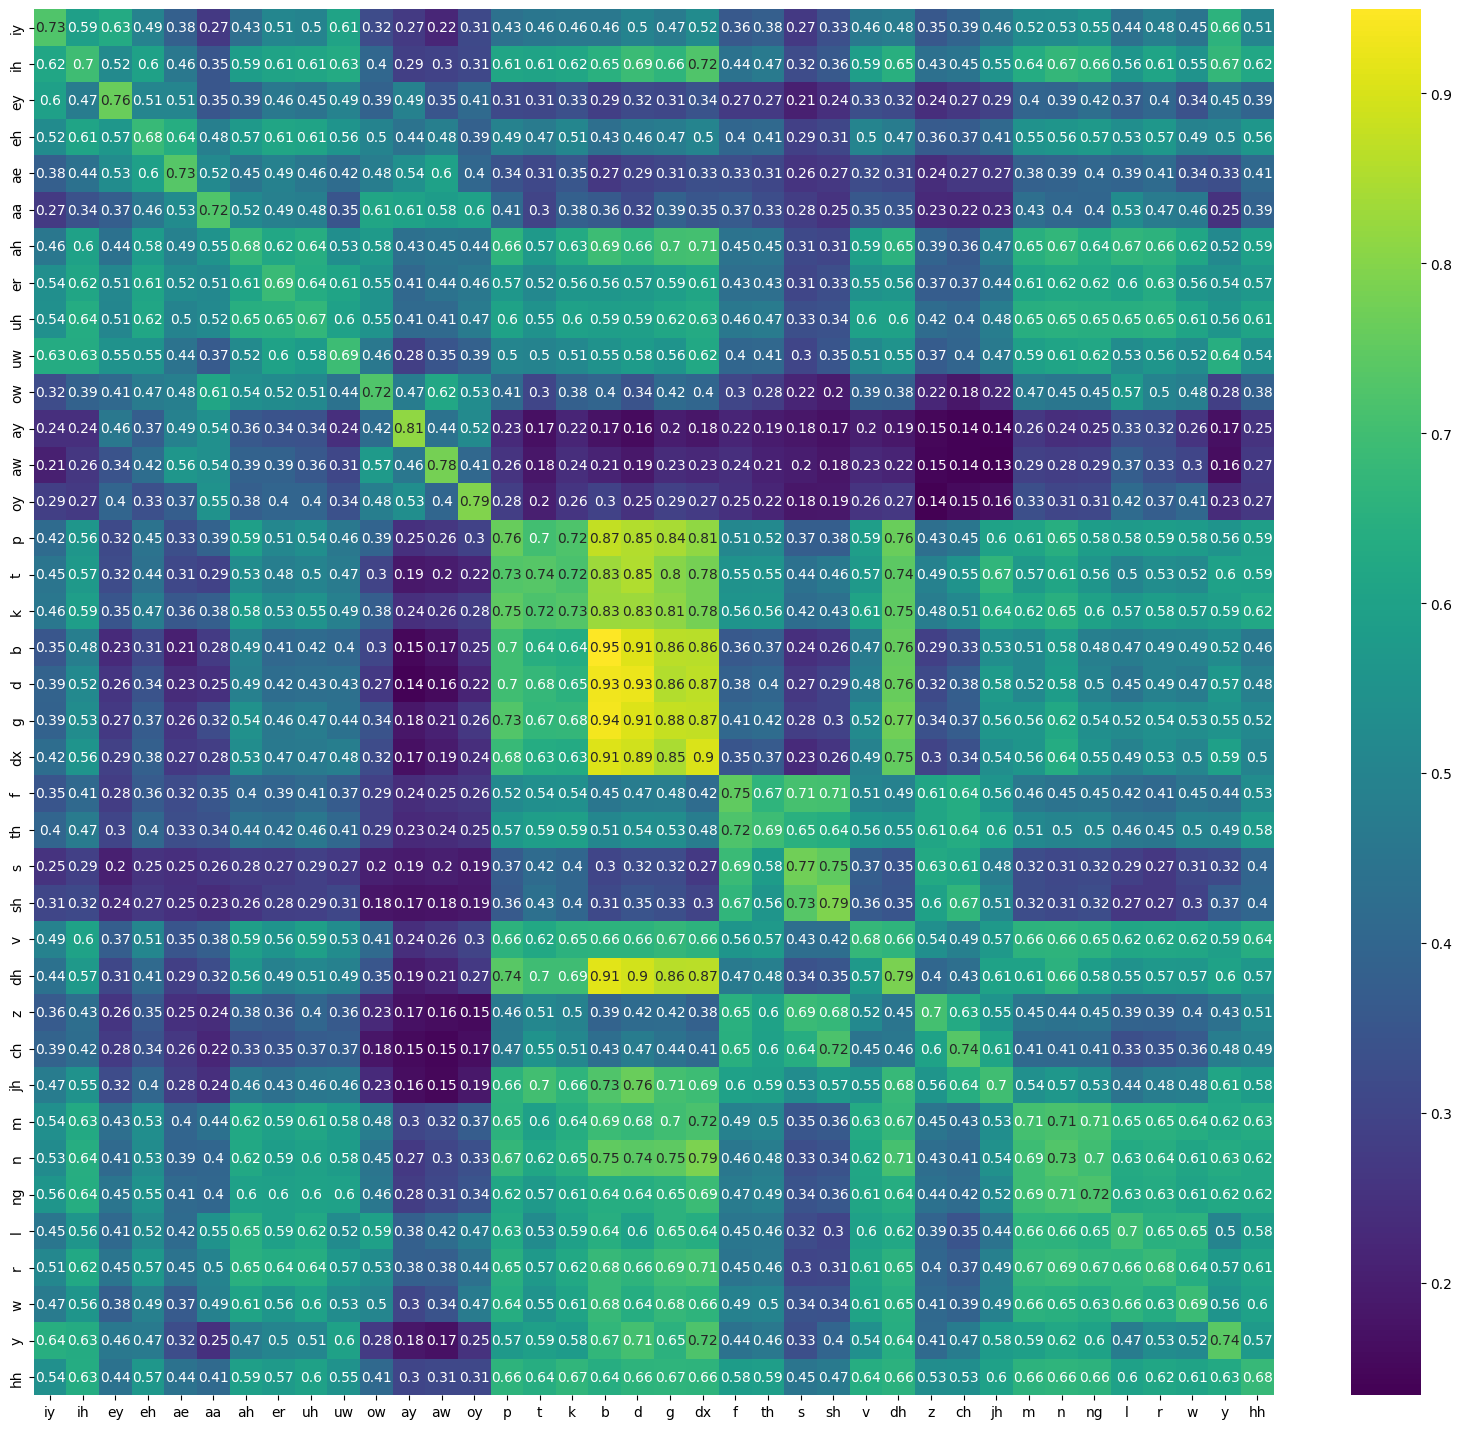

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20, 18))
sns.heatmap(heatmap, xticklabels=ordered_arpabet, yticklabels=ordered_arpabet, cmap='viridis', annot=True)

In [14]:
rocs = {}
for phone in ordered_arpabet:
    sims = cosine_similarity([centroids[phone]], df.feat.tolist())[0]
    indices = np.argsort(sims)[::-1]
    fpr, tpr, thresholds = roc_curve(df.iloc[indices].phone == phone, sims[indices])
    roc_auc = auc(fpr, tpr)
    rocs[phone] = (fpr, tpr, roc_auc)

<Figure size 640x480 with 0 Axes>

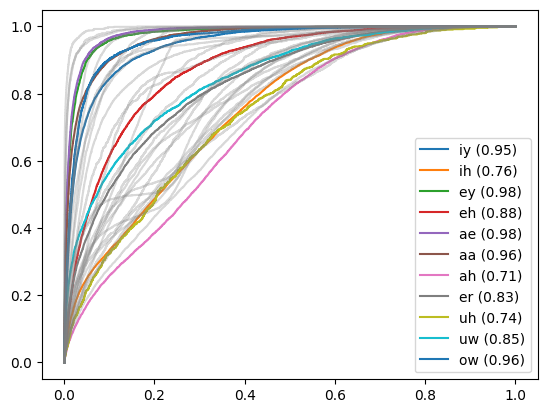

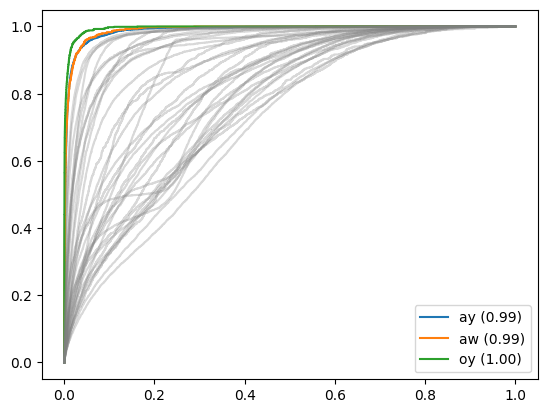

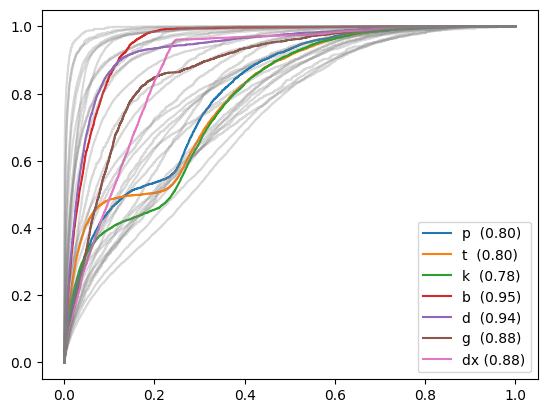

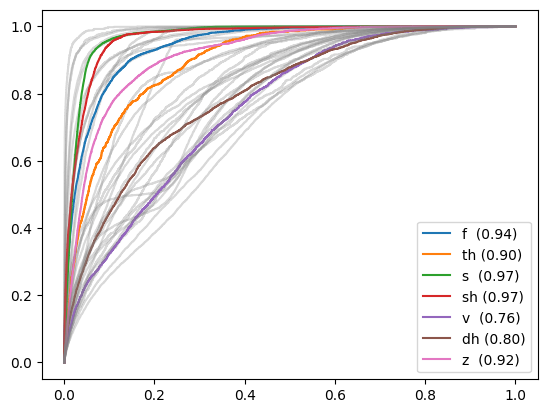

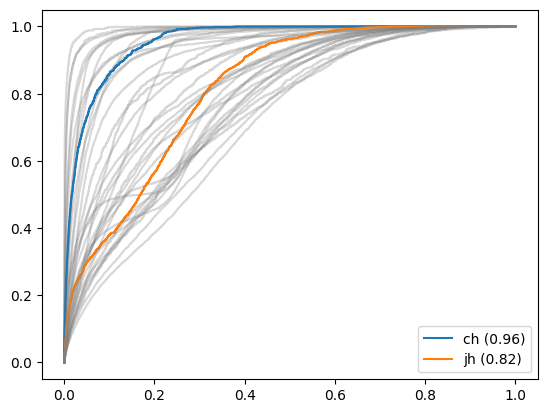

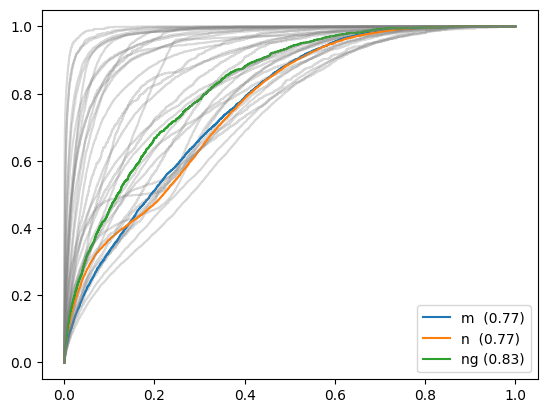

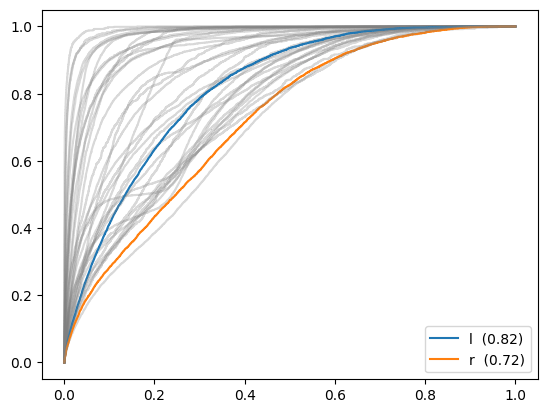

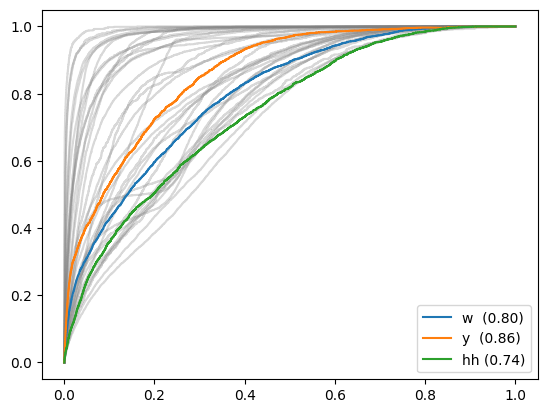

In [21]:
for group in arpabet_groups:
    plt.figure()
    for p in ordered_arpabet:
        fpr, tpr, roc_auc = rocs[p]
        if p in group:
            plt.plot(fpr, tpr, label=f'{p:2s} ({roc_auc:.2f})')
        else:
            plt.plot(fpr, tpr, c="gray", alpha=0.3)
    plt.legend()
    plt.show()

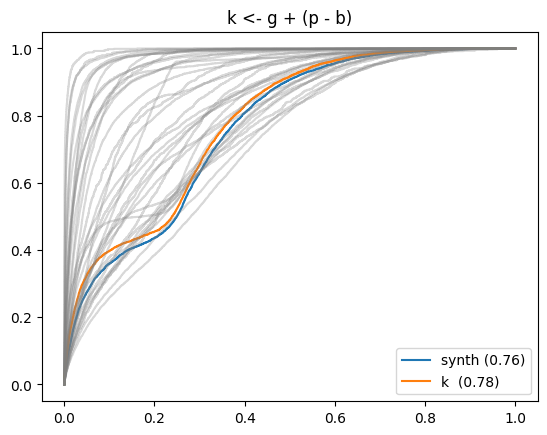

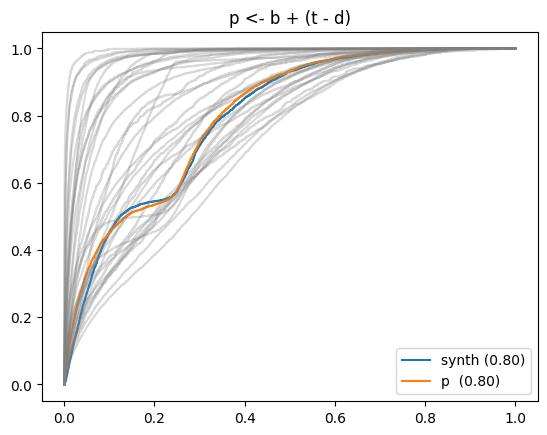

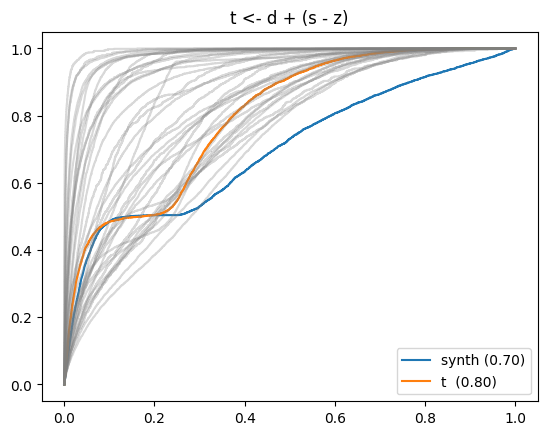

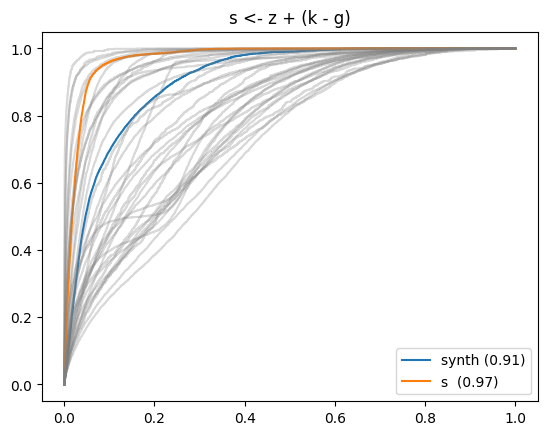

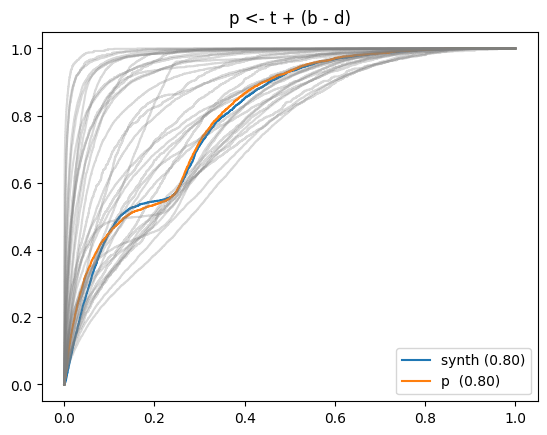

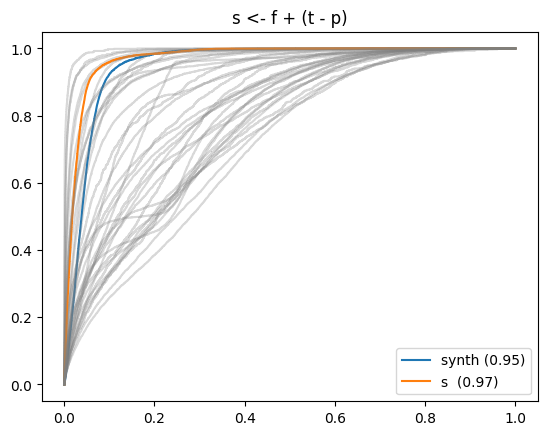

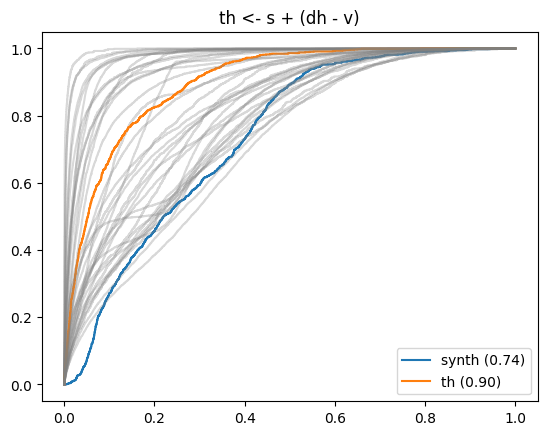

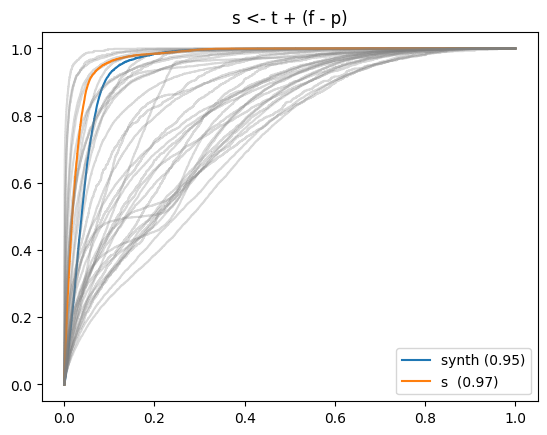

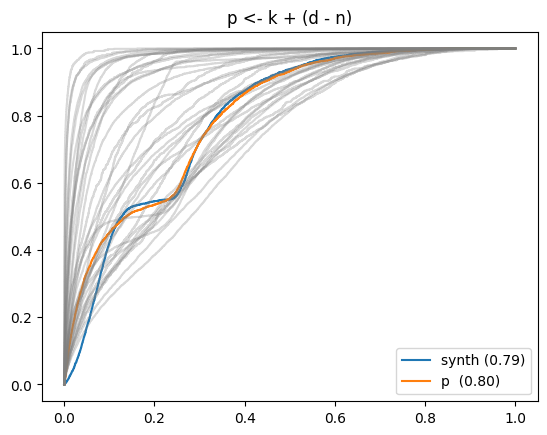

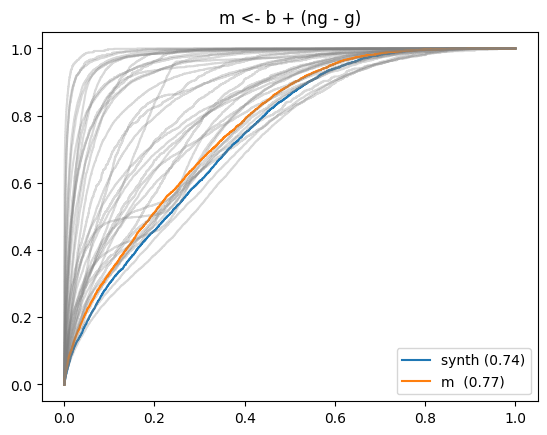

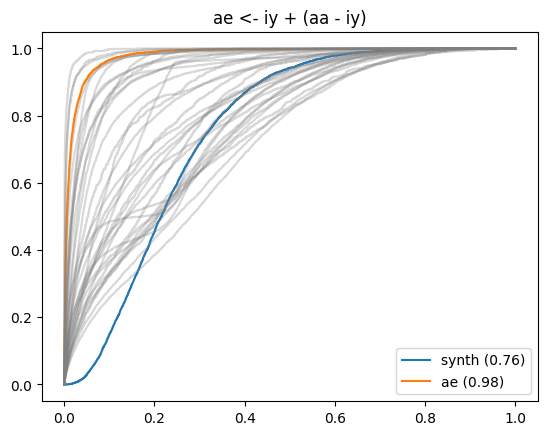

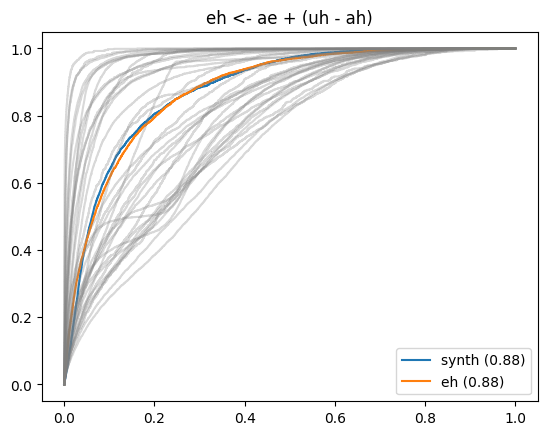

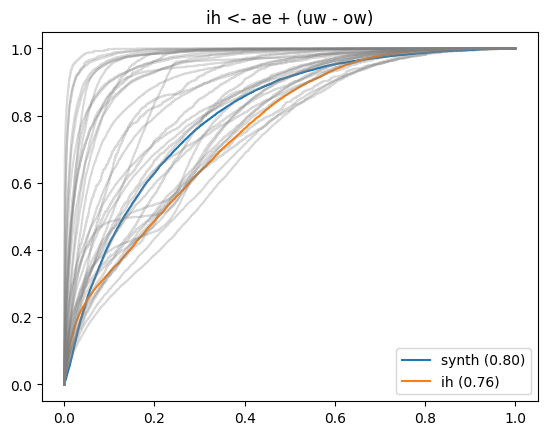

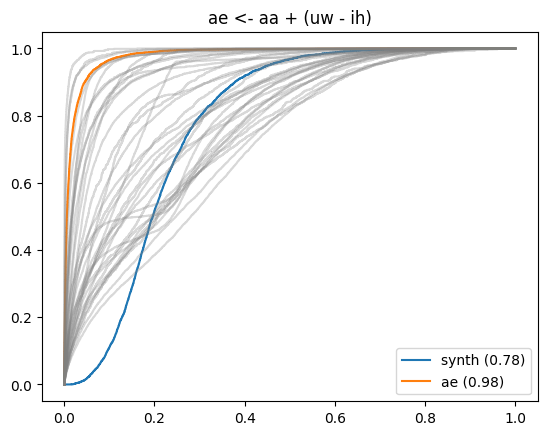

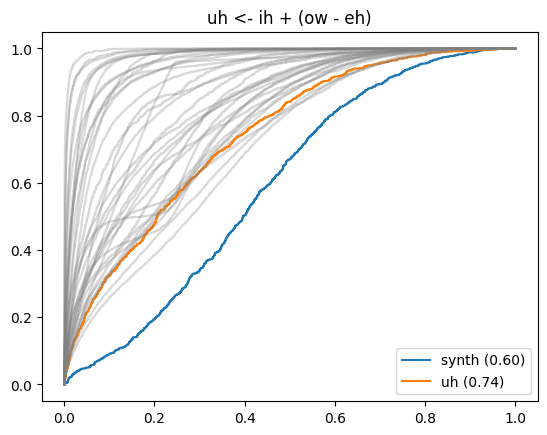

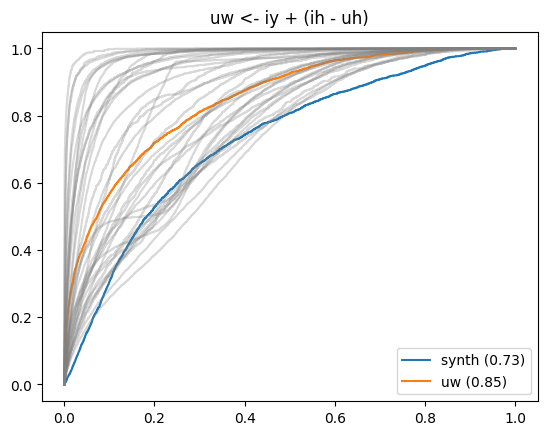

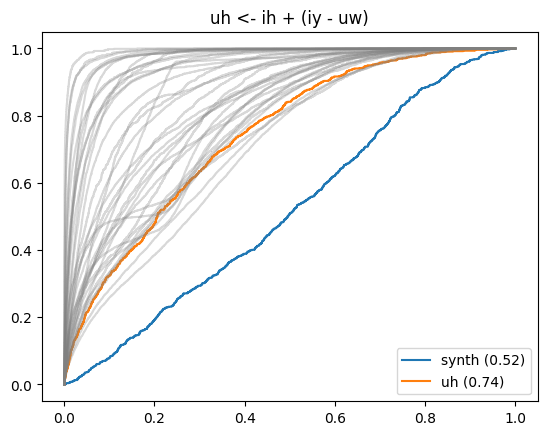

In [42]:
synth_sets = [
    # Consonant voicing
    ("k", "g", "p", "b"),
    ("p", "b", "t", "d"),
    ("t", "d", "s", "z"),
    ("s", "z", "k", "g"),

    # Consonant place
    ("p", "t", "b", "d"),
    ("s", "f", "t", "p"),
    ("th", "s", "dh", "v"),

    # Consonant manner
    ("s", "t", "f", "p"),
    ("p", "k", "d", "n"),
    ("m", "b", "ng", "g"),

    # Vowel openness
    ("ae", "iy", "aa", "iy"),
    ("eh", "ae", "uh", "ah"),
    ("ih", "ae", "uw", "ow"),

    # Vowel frontness
    ("ae", "aa", "uw", "ih"),
    ("uh", "ih", "ow", "eh"),

    # Vowel roundness
    ("uw", "iy", "ih", "uh"),
    ("uh", "ih", "iy", "uw"),
]

for target, init, v1, v2 in synth_sets:
    synth = _normalize(centroids[init] + centroids[v1] - centroids[v2])

    sims = cosine_similarity([synth], df.feat.tolist())[0]
    indices = np.argsort(sims)[::-1]
    fpr, tpr, thresholds = roc_curve(df.iloc[indices].phone == target, sims[indices])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'synth ({roc_auc:.2f})')
    for p in ordered_arpabet:
        fpr, tpr, roc_auc = rocs[p]
        if p == target:
            plt.plot(fpr, tpr, label=f'{p:2s} ({roc_auc:.2f})')
        else:
            plt.plot(fpr, tpr, c="gray", alpha=0.3)
    plt.title(f"{target} <- {init} + ({v1} - {v2})")
    plt.legend()
    plt.show()


In [43]:
def _random_sampler(df, phone):
    l_indices = df[df.phone == phone].index.to_numpy()
    r_indices = df.index.to_numpy()
    np.random.default_rng(seed=42).shuffle(r_indices)
    for l, r in zip(l_indices, r_indices):
        if l != r:
            yield l, r

def _speaker_sampler(df, phone):
    _df = df[df.phone == phone]
    for spk in _df.speaker.unique():
        l_indices = _df[_df.speaker == spk].index.to_numpy()
        r_indices = df[df.speaker == spk].index.to_numpy()
        np.random.default_rng(seed=42).shuffle(r_indices)
        for l, r in zip(l_indices, r_indices):
            if l != r:
                yield l, r

def _same_word_sampler(df, phone):
    l_indices = df[df.phone == phone].index.to_numpy()
    r_indices = l_indices.copy()
    np.random.default_rng(seed=42).shuffle(r_indices)
    for l, r in zip(l_indices, r_indices):
        if l != r:
            yield l, r

def _synth_word_sampler(df, phone, init, v1, v2):
    def _get_indices(p):
        return df[df.phone == p].index.to_numpy()
    def _shuffle(arr, seed=42):
        np.random.default_rng(seed=42).shuffle(arr)

    phone_i, init_i, v1_i, v2_i = _get_indices(phone), _get_indices(init), _get_indices(v1), _get_indices(v2)
    _shuffle(init_i), _shuffle(v1_i), _shuffle(v2_i)
    for phones in zip(phone_i, init_i, v1_i, v2_i):
        yield phones


print("Rule              : Rnd.  Spk.  Same  | Synth")
for target, init, v1, v2 in synth_sets:
    rand = np.mean([
        np.dot(df.iloc[l].feat, df.iloc[r].feat)
        for l, r in _random_sampler(df, target)
    ])
    spk = np.mean([
        np.dot(df.iloc[l].feat, df.iloc[r].feat)
        for l, r in _speaker_sampler(df, target)
    ])
    same = np.mean([
        np.dot(df.iloc[l].feat, df.iloc[r].feat)
        for l, r in _same_word_sampler(df, target)
    ])

    synth = _normalize(centroids[init] + centroids[v1] - centroids[v2])
    synth = np.mean([
        np.dot(df.iloc[target_i].feat, _normalize(df.iloc[init_i].feat + df.iloc[v1_i].feat - df.iloc[v2_i].feat))
        for target_i, init_i, v1_i, v2_i in _synth_word_sampler(df, target, init, v1, v2)
    ])
    print(f"{target:^3}<-{init:^3}+({v1:^3}-{v2:^3}): {rand:.3f} {spk:.3f} {same:.3f} | {synth:.3f}")


Rule              : Rnd.  Spk.  Same  | Synth
 k <- g +( p - b ): 0.409 0.403 0.532 | 0.484
 p <- b +( t - d ): 0.413 0.412 0.576 | 0.499
 t <- d +( s - z ): 0.392 0.387 0.539 | 0.425
 s <- z +( k - g ): 0.268 0.281 0.594 | 0.403
 p <- t +( b - d ): 0.422 0.412 0.576 | 0.499
 s <- f +( t - p ): 0.271 0.281 0.594 | 0.415
th <- s +(dh - v ): 0.335 0.338 0.474 | 0.319
 s <- t +( f - p ): 0.267 0.281 0.594 | 0.415
 p <- k +( d - n ): 0.417 0.412 0.576 | 0.479
 m <- b +(ng - g ): 0.411 0.405 0.499 | 0.443
ae <-iy +(aa -iy ): 0.295 0.294 0.537 | 0.379
eh <-ae +(uh -ah ): 0.352 0.347 0.469 | 0.317
ih <-ae +(uw -ow ): 0.396 0.388 0.484 | 0.318
ae <-aa +(uw -ih ): 0.292 0.294 0.537 | 0.252
uh <-ih +(ow -eh ): 0.384 0.380 0.444 | 0.271
uw <-iy +(ih -uh ): 0.362 0.362 0.480 | 0.301
uh <-ih +(iy -uw ): 0.387 0.380 0.444 | 0.275


In [ ]:
# https://legacy.cs.indiana.edu/ftp/techreports/TR406.pdf
# def rotate_like(l, r, a):
#     # assume l, r, a are 1‑D numpy arrays already normalised
#     theta = np.arccos(np.clip(l @ r, -1.0, 1.0))
#     if theta < 1e-12:
#         return a.copy()               # l ≈ r ⇒ identity
#     u = r
#     v = l - (l @ u) * u
#     v /= np.linalg.norm(v)
#     I   = np.eye(len(a))
#     R   = (I +
#            np.sin(theta) * (np.outer(v, u) - np.outer(u, v)) +
#            (np.cos(theta) - 1) * (np.outer(u, u) + np.outer(v, v)))
#     return R @ a
# https://math.stackexchange.com/questions/197772/generalized-rotation-matrix-in-n-dimensional-space-around-n-2-unit-vector